# Setting up the dependencies

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

In [2]:
torch.manual_seed(42)
np.random.seed(42)

# Creating the Dataset
This block creates and prepares a synthetic dataset for a binary classification task (like predicting whether a user clicks an ad). First, make_classification generates 5,000 samples with 20 features, of which some are informative and some redundant to simulate real-world data complexity. The dataset is then split into training and testing sets to evaluate model performance on unseen data.

Next, StandardScaler normalizes the features so they have a consistent scale, which helps neural networks train more efficiently. The data is then converted into PyTorch tensors so it can be used in model training. Finally, a DataLoader is created to feed the data in mini-batches (size 64) during training, improving efficiency and enabling stochastic gradient descent.


In [3]:
X, y = make_classification(
    n_samples=5000, n_features=20, n_informative=10,
    n_redundant=5, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t  = torch.tensor(y_train, dtype=torch.long)
X_test_t   = torch.tensor(X_test,  dtype=torch.float32)
y_test_t   = torch.tensor(y_test,  dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True
)

# Model Architecture
This section defines two neural network architectures: a TeacherModel and a StudentModel. The teacher represents one of the large models in the ensemble—it has multiple layers, wider dimensions, and dropout for regularization, making it highly expressive but computationally expensive during inference.
The student model, on the other hand, is a smaller and more efficient network with fewer layers and parameters. Its goal is not to match the teacher’s complexity, but to learn its behavior through distillation. Importantly, the student still retains enough capacity to approximate the teacher’s decision boundaries—too small, and it won’t be able to capture the richer patterns learned by the ensemble.

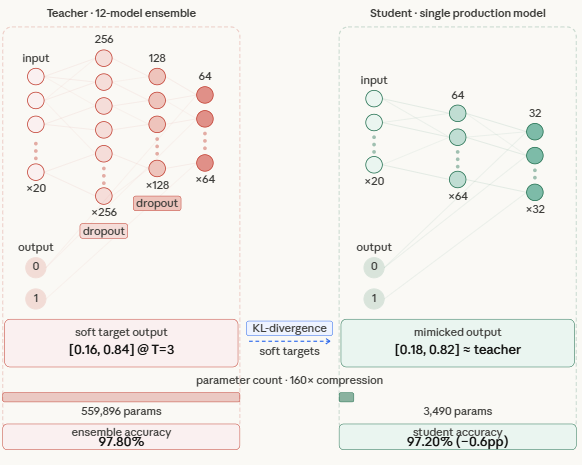


In [12]:
class TeacherModel(nn.Module):
    """Represents one heavy model inside the ensemble."""
    def __init__(self, input_dim=20, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)


class StudentModel(nn.Module):
    """
    The lean production model that learns from the ensemble.
    Two hidden layers — enough capacity to absorb distilled
    knowledge, still ~30x smaller than the full ensemble.
    """
    def __init__(self, input_dim=20, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32),        nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        return self.net(x)

# Helper Functions
This section defines two utility functions for training and evaluation.

train_one_epoch handles one full pass over the training data. It puts the model in training mode, iterates through mini-batches, computes the loss, performs backpropagation, and updates the model weights using the optimizer. It also tracks and returns the average loss across all batches to monitor training progress.

evaluate is used to measure model performance. It switches the model to evaluation mode (disabling dropout and gradients), makes predictions on the input data, and computes the accuracy by comparing predicted labels with true labels.


In [13]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, X, y):
    model.eval()
    with torch.no_grad():
        preds = model(X).argmax(dim=1)
    return (preds == y).float().mean().item()

# Training the Ensemble
This section trains the teacher ensemble, which serves as the source of knowledge for distillation. Instead of a single model, 12 teacher models are trained independently with different random initializations, allowing each one to learn slightly different patterns from the data. This diversity is what makes ensembles powerful.

Each teacher is trained for multiple epochs until convergence, and their individual test accuracies are printed. Once all models are trained, their predictions are combined using soft voting—by averaging their output logits rather than taking a simple majority vote. This produces a stronger, more stable final prediction, giving you a high-performing ensemble that will act as the “teacher” in the next step.


In [14]:
print("=" * 55)
print("STEP 1: Training the 12-model Teacher Ensemble")
print("        (this happens offline, not in production)")
print("=" * 55)

NUM_TEACHERS = 12
teachers = []

for i in range(NUM_TEACHERS):
    torch.manual_seed(i)                           # different init per teacher
    model = TeacherModel()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(30):                        # train until convergence
        train_one_epoch(model, train_loader, optimizer, criterion)

    acc = evaluate(model, X_test_t, y_test_t)
    print(f"  Teacher {i+1:02d} -> test accuracy: {acc:.4f}")
    model.eval()
    teachers.append(model)

# Soft voting: average logits across all teachers (stronger than majority vote)
with torch.no_grad():
    avg_logits     = torch.stack([t(X_test_t) for t in teachers], dim=0).mean(dim=0)
    ensemble_preds = avg_logits.argmax(dim=1)
ensemble_acc = (ensemble_preds == y_test_t).float().mean().item()
print(f"\n  Ensemble (soft vote) accuracy: {ensemble_acc:.4f}")

STEP 1: Training the 12-model Teacher Ensemble
        (this happens offline, not in production)
  Teacher 01 -> test accuracy: 0.9780
  Teacher 02 -> test accuracy: 0.9740
  Teacher 03 -> test accuracy: 0.9730
  Teacher 04 -> test accuracy: 0.9710
  Teacher 05 -> test accuracy: 0.9770
  Teacher 06 -> test accuracy: 0.9730
  Teacher 07 -> test accuracy: 0.9770
  Teacher 08 -> test accuracy: 0.9750
  Teacher 09 -> test accuracy: 0.9790
  Teacher 10 -> test accuracy: 0.9750
  Teacher 11 -> test accuracy: 0.9710
  Teacher 12 -> test accuracy: 0.9770

  Ensemble (soft vote) accuracy: 0.9780


# Generating Soft Targets from the Ensemble
This step generates soft targets from the trained teacher ensemble, which are the key ingredient in knowledge distillation. Instead of using hard labels (0 or 1), the ensemble’s averaged predictions are converted into probability distributions, capturing how confident the model is across all classes.

The function first averages the logits from all teachers (soft voting), then applies temperature scaling to smooth the probabilities. A higher temperature (like 3.0) makes the distribution softer, revealing subtle relationships between classes that hard labels cannot capture. These soft targets provide richer learning signals, allowing the student model to better approximate the ensemble’s behavior.


In [15]:
TEMPERATURE = 3.0   # controls how "soft" the teacher's output is

def get_ensemble_soft_targets(teachers, X, T):
    """
    Average logits from all teachers, then apply temperature scaling.
    Soft targets carry richer signal than hard 0/1 labels.
    """
    with torch.no_grad():
        logits = torch.stack([t(X) for t in teachers], dim=0).mean(dim=0)
    return F.softmax(logits / T, dim=1)   # soft probability distribution

soft_targets = get_ensemble_soft_targets(teachers, X_train_t, TEMPERATURE)

print(f"\n  Sample hard label : {y_train_t[0].item()}")
print(f"  Sample soft target: [{soft_targets[0,0]:.4f}, {soft_targets[0,1]:.4f}]")
print("  -> Soft target carries confidence info, not just class identity.")


  Sample hard label : 1
  Sample soft target: [0.1382, 0.8618]
  -> Soft target carries confidence info, not just class identity.


# Distillation: Training the Student
This section trains the student model using knowledge distillation, where it learns from both the teacher ensemble and the true labels. A new dataloader is created that provides inputs along with hard labels and soft targets together.

During training, two losses are computed:

* Distillation loss (KL-divergence) encourages the student to match the teacher’s softened probability distribution, transferring the ensemble’s “knowledge.”
* Hard label loss (cross-entropy) ensures the student still aligns with the ground truth.

These are combined using a weighting factor (ALPHA), where a higher value gives more importance to the teacher’s guidance. Temperature scaling is applied again to keep consistency with the soft targets, and a rescaling factor ensures stable gradients. Over multiple epochs, the student gradually learns to approximate the ensemble’s behavior while remaining much smaller and efficient for deployment.


In [16]:
print("\n" + "=" * 55)
print("STEP 2: Training the Student via Knowledge Distillation")
print("        (this produces the single production model)")
print("=" * 55)

ALPHA  = 0.7    # weight on distillation loss (0.7 = mostly soft targets)
EPOCHS = 50

student    = StudentModel()
optimizer  = torch.optim.Adam(student.parameters(), lr=1e-3, weight_decay=1e-4)
ce_loss_fn = nn.CrossEntropyLoss()

# Dataloader that yields (inputs, hard labels, soft targets) together
distill_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t, soft_targets),
    batch_size=64, shuffle=True
)

for epoch in range(EPOCHS):
    student.train()
    epoch_loss = 0

    for xb, yb, soft_yb in distill_loader:
        optimizer.zero_grad()

        student_logits = student(xb)

        # (1) Distillation loss: match the teacher's soft distribution
        #     KL-divergence between student and teacher outputs at temperature T
        student_soft = F.log_softmax(student_logits / TEMPERATURE, dim=1)
        distill_loss = F.kl_div(student_soft, soft_yb, reduction='batchmean')
        distill_loss *= TEMPERATURE ** 2   # rescale: keeps gradient magnitude
                                           # stable across different T values

        # (2) Hard label loss: also learn from ground truth
        hard_loss = ce_loss_fn(student_logits, yb)

        # Combined loss
        loss = ALPHA * distill_loss + (1 - ALPHA) * hard_loss
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        acc = evaluate(student, X_test_t, y_test_t)
        print(f"  Epoch {epoch+1:02d}/{EPOCHS}  loss: {epoch_loss/len(distill_loader):.4f}  "
              f"student accuracy: {acc:.4f}")


STEP 2: Training the Student via Knowledge Distillation
        (this produces the single production model)
  Epoch 10/50  loss: 0.2580  student accuracy: 0.9560
  Epoch 20/50  loss: 0.1106  student accuracy: 0.9700
  Epoch 30/50  loss: 0.0609  student accuracy: 0.9700
  Epoch 40/50  loss: 0.0414  student accuracy: 0.9720
  Epoch 50/50  loss: 0.0324  student accuracy: 0.9720


# Student trained on on Hard Labels only
This section trains a baseline student model without knowledge distillation, using only the ground truth labels. The architecture is identical to the distilled student, ensuring a fair comparison.

The model is trained in the standard way with cross-entropy loss, learning directly from hard labels without any guidance from the teacher ensemble. After training, its accuracy is evaluated on the test set.

This baseline acts as a reference point—allowing you to clearly measure how much performance gain comes specifically from distillation, rather than just the student model’s capacity or training process.


In [17]:
print("\n" + "=" * 55)
print("BASELINE: Student trained on hard labels only (no distillation)")
print("=" * 55)

baseline_student = StudentModel()
b_optimizer = torch.optim.Adam(
    baseline_student.parameters(), lr=1e-3, weight_decay=1e-4
)

for epoch in range(EPOCHS):
    train_one_epoch(baseline_student, train_loader, b_optimizer, ce_loss_fn)

baseline_acc = evaluate(baseline_student, X_test_t, y_test_t)
print(f"  Baseline student accuracy: {baseline_acc:.4f}")


BASELINE: Student trained on hard labels only (no distillation)
  Baseline student accuracy: 0.9650


# Comparison
To measure how much the ensemble's knowledge actually transfers, we run three models against the same held-out test set. The ensemble — all 12 teachers voting together via averaged logits — sets the accuracy ceiling at 97.80%. This is the number we are trying to approximate, not beat. The baseline student is an identical single-model architecture trained the conventional way, on hard labels only: it sees each sample as a binary 0 or 1, nothing more. It lands at 96.50%. The distilled student is the same architecture again, but trained on the ensemble's soft probability outputs at temperature T=3, with a combined loss weighted 70% toward matching the teacher's distribution and 30% toward ground truth labels. It reaches 97.20%.

The 0.70 percentage point gap between the baseline and the distilled student is not a coincidence of random seed or training noise — it is the measurable value of the soft targets. The student did not get more data, a better architecture, or more computation. It got a richer training signal, and that alone recovered 53.8% of the gap between what a small model can learn on its own and what the full ensemble knows. The remaining gap of 0.60 percentage points between the distilled student and the ensemble is the honest cost of compression — the portion of the ensemble's knowledge that a 3,490-parameter model simply cannot hold, regardless of how well it is trained.

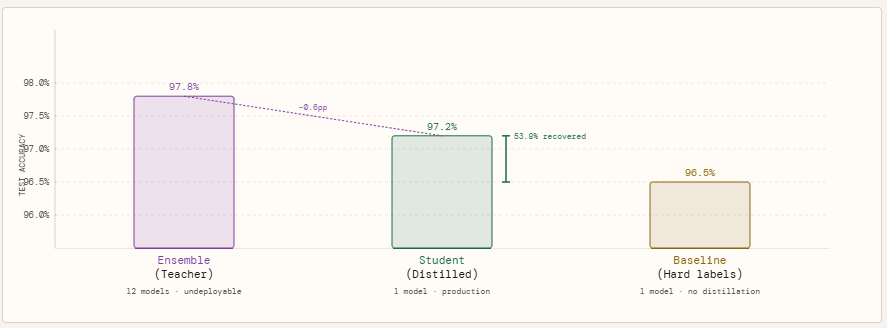

In [18]:
distilled_acc = evaluate(student, X_test_t, y_test_t)

print("\n" + "=" * 55)
print("RESULTS SUMMARY")
print("=" * 55)
print(f"  Ensemble  (12 models, production-undeployable) : {ensemble_acc:.4f}")
print(f"  Student   (distilled, production-ready)        : {distilled_acc:.4f}")
print(f"  Baseline  (student, hard labels only)          : {baseline_acc:.4f}")

gap      = ensemble_acc - distilled_acc
recovery = (distilled_acc - baseline_acc) / max(ensemble_acc - baseline_acc, 1e-9)
print(f"\n  Accuracy gap vs ensemble       : {gap:.4f}")
print(f"  Knowledge recovered vs baseline: {recovery*100:.1f}%")


RESULTS SUMMARY
  Ensemble  (12 models, production-undeployable) : 0.9780
  Student   (distilled, production-ready)        : 0.9720
  Baseline  (student, hard labels only)          : 0.9650

  Accuracy gap vs ensemble       : 0.0060
  Knowledge recovered vs baseline: 53.8%


In [19]:
def count_params(m):
    return sum(p.numel() for p in m.parameters())

single_teacher_params = count_params(teachers[0])
student_params        = count_params(student)

print(f"\n  Single teacher parameters : {single_teacher_params:,}")
print(f"  Full ensemble parameters  : {single_teacher_params * NUM_TEACHERS:,}")
print(f"  Student parameters        : {student_params:,}")
print(f"  Size reduction            : {single_teacher_params * NUM_TEACHERS / student_params:.0f}x")


  Single teacher parameters : 46,658
  Full ensemble parameters  : 559,896
  Student parameters        : 3,490
  Size reduction            : 160x


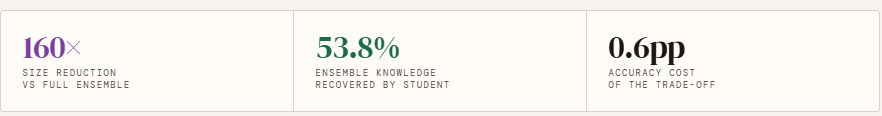